In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 3060 Laptop GPU
11.8
['sm_37', 'sm_50', 'sm_60', 'sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'compute_37']


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import numpy as np

# seed = 4
# torch.manual_seed(seed)
# np.random.seed(seed)
#
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [5]:
exclude_rgb_vis=False
exclude_weather_features=True
exclude_canopy_temp=True
dataset_name = "stratified_train_test_datasets_v3.xlsx"

In [6]:
from features import *

vi_features = get_vi_features(exclude_rgb_vis=exclude_rgb_vis)
weather_features = get_weather_features(exclude=exclude_weather_features)
canopy_temp_features = get_canopy_temp_features(exclude=exclude_canopy_temp)
features = vi_features + weather_features + canopy_temp_features

output_variable = get_output_variable()

Text(0.5, 1.0, 'Train vs Test Yield Distribution')

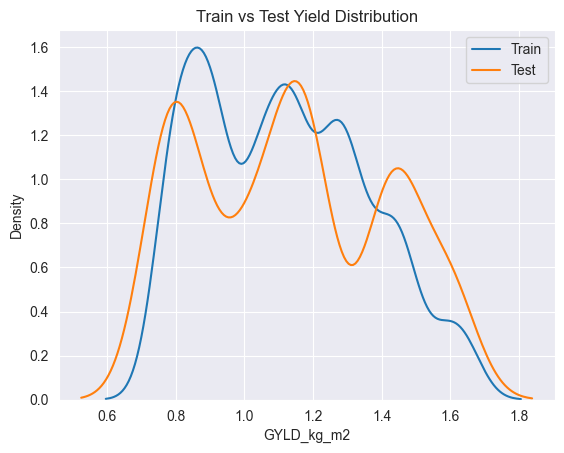

In [7]:
# Loading saved training test
train_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Train')
test_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [9]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1167
test_df_scaled Rows with at least one NaN: 364


In [ ]:
# print(X_test_scaled.shape)

In [10]:

def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch, lengths in model_train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch, lengths)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def evaluate_model(model, val_loader, output_variable_scaler, do_inverse_transform = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if do_inverse_transform:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse, mae

In [12]:
def predict_yield(model, val_loader, output_variable_scaler, do_inverse_transform = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if do_inverse_transform:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    return y_true, y_pred

In [13]:
window_size = 30
pad_value = 0

In [14]:
from torch.nn.utils.rnn import pack_padded_sequence
from helper import make_progressive_windows
from vi_dataset import VIDataset
from model_definitions import  GRUModel
from torch.utils.data import DataLoader

def validation_with_test(trial_id, batch_size, epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled, lengths_train, no_days_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled, lengths_test, no_days_test = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

    train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1 , dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader,
        num_epochs = epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse, mae = evaluate_model(
        model = model,
        val_loader = test_loader,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [ ]:
import optuna
from sklearn.metrics import r2_score

epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=180)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

In [15]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import GRUModel


# Best R²: 0.2857
# saved as /best_gru_models/best_model_hyper_param_3.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.07420456457400194, 'lr': 0.00981026753766152, 'weight_decay': 8.506150589531528e-08, 'batch_size': 16}

# Best R²: 0.18 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.01882176215855477, 'lr': 0.007580682214882081, 'weight_decay': 1.416934618280146e-06, 'batch_size': 64}

# Best R²: 0.2585 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 1, 'dropout': 0.47771061284348876, 'lr': 0.007432078216397578, 'weight_decay': 2.757922254289341e-07, 'batch_size': 32}

# Best R²: 0.5396, Test MSE: 0.0347
# saved as /best_gru_models/best_model_hyper_param_5.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.4116615584951404, 'lr': 0.00011452360758206809, 'weight_decay': 2.955054638657815e-08, 'batch_size': 8}


# best_gru_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.4976259917429097, 'lr': 0.0008701386766216585, 'weight_decay': 2.7353019000288583e-08, 'batch_size': 64}

# window size = 40
# Dataset: v3
# Test R²: 0.4961, Test MSE: 0.0379, Test MAE: 0.1572, max R²: 0.6857118606567383
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.14212952905983112, 'lr': 0.006344969970535884, 'weight_decay': 3.119218313061341e-05, 'batch_size': 8}


# window size = 20
# Dataset: v3
# Test R²: 0.4274, Test MSE: 0.0431, Test MAE: 0.1660, max R²: 0.7529662251472473
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.15407524085698027, 'lr': 0.00022516408745938045, 'weight_decay': 0.0001017303692011807, 'batch_size': 64}

# window size = 25
# Dataset: v3
# Test R²: 0.5003, Test MSE: 0.0376, Test MAE: 0.1589, max R²: 0.7332429885864258
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params =  {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.10503772376300814, 'lr': 0.00011690368125953273, 'weight_decay': 0.0009878712546328788, 'batch_size': 32}



# window size = 35
# Dataset: v3
# Test R²: 0.5235, Test MSE: 0.0359, Test MAE: 0.1540, max R²: 0.6950720548629761
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.15733282331703996, 'lr': 0.00048561958669596813, 'weight_decay': 0.00018153262022945748, 'batch_size': 32}


# window size = 30
# Dataset: v3
# Test R²: 0.6594, Test MSE: 0.0256, Test MAE: 0.1284, max R²: 0.8772286772727966
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
best_gru_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.22409349655400995, 'lr': 0.00015915047354193095, 'weight_decay': 7.29888035700565e-09, 'batch_size': 64}



best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [16]:
from helper import make_progressive_windows
from vi_dataset import VIDataset
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

X_train_scaled, y_train_scaled, valid_length_train, no_days_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled, valid_length_test, no_days_test = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

Processing plot 10_d
Processing plot 10_w
Processing plot 11_d
Processing plot 11_w
Processing plot 12_d
Processing plot 12_w
Processing plot 13_d
Processing plot 13_w
Processing plot 14_w
Processing plot 15_d
Processing plot 15_w
Processing plot 16_w
Processing plot 17_d
Processing plot 18_d
Processing plot 19_d
Processing plot 19_w
Processing plot 1_w
Processing plot 20_w
Processing plot 21_d
Processing plot 21_w
Processing plot 22_w
Processing plot 23_d
Processing plot 24_d
Processing plot 24_w
Processing plot 2_d
Processing plot 2_w
Processing plot 3_d
Processing plot 3_w
Processing plot 4_d
Processing plot 5_d
Processing plot 5_w
Processing plot 6_d
Processing plot 7_w
Processing plot 8_d
Processing plot 8_w
Processing plot 9_d
Processing plot 9_w
Processing plot 14_d
Processing plot 16_d
Processing plot 17_w
Processing plot 18_w
Processing plot 1_d
Processing plot 20_d
Processing plot 23_w
Processing plot 4_w
Processing plot 6_w
Processing plot 7_d


In [17]:

train_dataset = VIDataset(X_train_scaled, y_train_scaled, valid_length_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, valid_length_test)


train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:
# Optional: Train again with best hyper parameters

epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

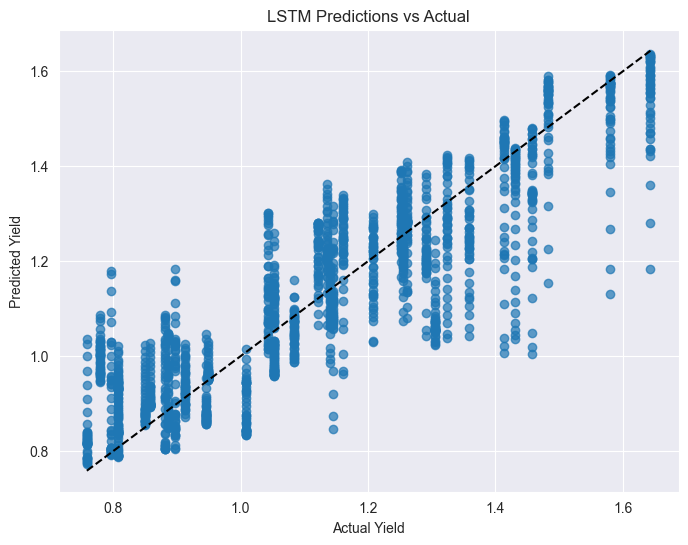

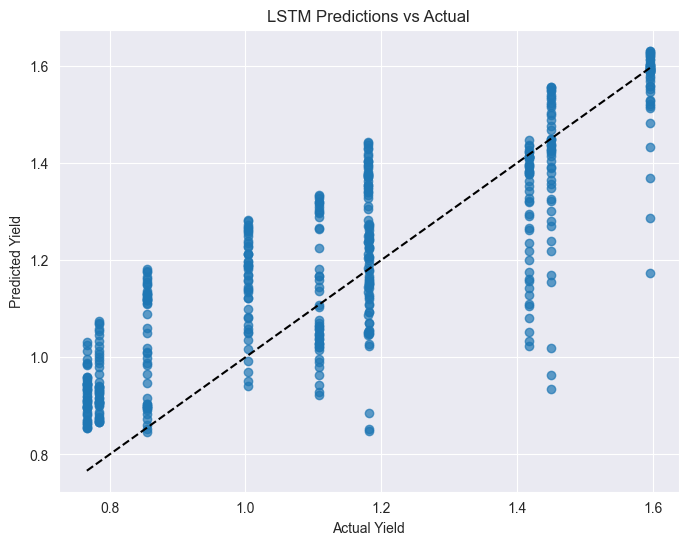

Train R²: 0.7692, Train MSE: 0.0132, Train MAE: 0.0867
Test R²: 0.6595, Test MSE: 0.0256, Test MAE: 0.1284


In [18]:
# from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_gru_models/best_model_hyper_param_11.pth", map_location=device))

# Training metrics
r2_train, mse_train, mae_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test, mae_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}, Test MAE: {mae_test:.4f}')


In [19]:
from helper import filter_window_data_by_length

total_n_days = 46 # (from may 1st to June 15th)

test_r2 = []
test_mse = []
test_mae = []
for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered = filter_window_data_by_length(
    X_train_scaled, y_train_scaled, valid_length_train, no_days_train, filter_day
    )

    # test
    X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered = filter_window_data_by_length(
        X_test_scaled, y_test_scaled, valid_length_test, no_days_test, filter_day
    )

    train_dataset_filtered = VIDataset(X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered)
    test_dataset_filtered = VIDataset(X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered)

    train_loader_filtered  = DataLoader(train_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=True)
    test_loader_filtered    = DataLoader(test_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=False)

    # Training metrics
    r2_train_filtered, mse_train_filtered, mae_train_filtered = evaluate_model(best_model, train_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)
    # Test metrics
    r2_test_filtered, mse_test_filtered, mae_test_filtered = evaluate_model(best_model, test_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)

    print(f'Train R²: {r2_train_filtered:.4f}, Train MSE: {mse_train_filtered:.4f}, Train MAE: {mae_train_filtered:.4f}')
    print(f'Test R²: {r2_test_filtered:.4f}, Test MSE: {mse_test_filtered:.4f}, Test MAE: {mae_test_filtered:.4f}')
    test_r2.append(r2_test_filtered)
    test_mse.append(mse_test_filtered)
    test_mae.append(mae_test_filtered)


day: 1
Train R²: 0.0914, Train MSE: 0.0521, Train MAE: 0.1907
Test R²: 0.2543, Test MSE: 0.0561, Test MAE: 0.2038
day: 2
Train R²: 0.1990, Train MSE: 0.0460, Train MAE: 0.1775
Test R²: 0.4388, Test MSE: 0.0423, Test MAE: 0.1835
day: 3
Train R²: 0.3307, Train MSE: 0.0384, Train MAE: 0.1607
Test R²: 0.5328, Test MSE: 0.0352, Test MAE: 0.1748
day: 4
Train R²: 0.4133, Train MSE: 0.0337, Train MAE: 0.1542
Test R²: 0.5702, Test MSE: 0.0324, Test MAE: 0.1658
day: 5
Train R²: 0.4783, Train MSE: 0.0299, Train MAE: 0.1461
Test R²: 0.5782, Test MSE: 0.0318, Test MAE: 0.1570
day: 6
Train R²: 0.5352, Train MSE: 0.0267, Train MAE: 0.1378
Test R²: 0.6092, Test MSE: 0.0294, Test MAE: 0.1474
day: 7
Train R²: 0.5939, Train MSE: 0.0233, Train MAE: 0.1291
Test R²: 0.6445, Test MSE: 0.0268, Test MAE: 0.1380
day: 8
Train R²: 0.6393, Train MSE: 0.0207, Train MAE: 0.1229
Test R²: 0.6625, Test MSE: 0.0254, Test MAE: 0.1307
day: 9
Train R²: 0.6776, Train MSE: 0.0185, Train MAE: 0.1162
Test R²: 0.6602, Test MSE:

In [20]:
import numpy as np

print(np.mean(test_r2))
print(np.min(test_r2))
print(np.max(test_r2))

print(np.mean(test_mse))
print(np.max(test_mse))
print(np.min(test_mse))

print(np.mean(test_mae))
print(np.max(test_mae))
print(np.min(test_mae))

0.659456878900528
0.15226173400878906
0.8771833181381226
0.025639586960491928
0.06382645666599274
0.009246899746358395
0.1283742045254811
0.20379915833473206
0.07733406871557236


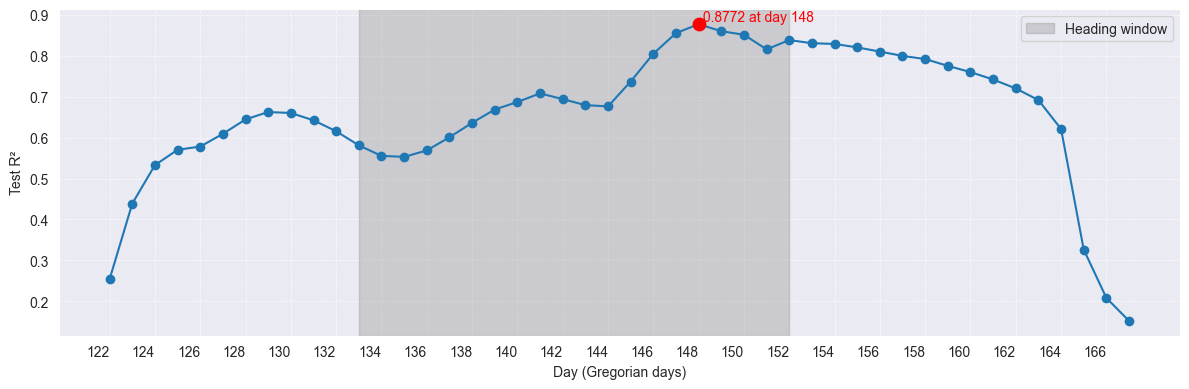

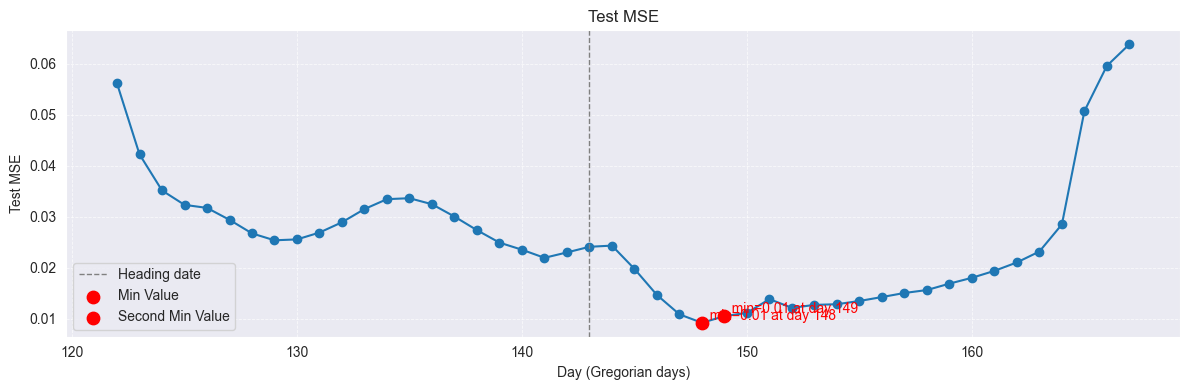

In [21]:
from plots import plot_r2, plot_mse

plot_r2(test_r2, total_n_days)
plot_mse(test_mse, total_n_days)

In [63]:
test_df_scaled

,date,plot_id,ndvi_noir_rgb_method,gndvi_noir_rgb_method,rdvi_noir_rgb_method,savi_noir_rgb_method,sr_noir_rgb_method,evi_noir_rgb_method,cigreen_noir_rgb_method,gli,...,lepton_mean_temp,lepton_min_temp,lepton_max_temp,Solar,Precipitation,AirTemp,Vapor_Pressure,AtmPressure,RelHumidity,GYLD_kg_m2
0,2024-05-01,14_d,-0.351645,-0.753008,-0.377877,-0.379236,-0.487110,-0.329485,-0.784549,-0.432326,...,24.460153,20.674524,30.479355,844.833333,0.000000,12.400000,0.646667,97.566667,0.451000,0.152950
1,2024-05-02,14_d,-0.252322,-0.658197,-0.271253,-0.270593,-0.403270,-0.213987,-0.710197,-0.326990,...,34.736689,33.169168,36.319429,835.083333,0.000000,14.600000,0.729167,97.191667,0.441750,0.152950
2,2024-05-03,14_d,0.377677,0.021867,0.512292,0.558237,0.188170,0.657529,-0.135875,0.369134,...,17.662139,16.705180,19.636209,824.333333,0.000000,16.058333,0.830000,97.266667,0.458167,0.152950
3,2024-05-04,14_d,0.695364,0.354921,0.948684,1.030866,0.496723,1.177263,0.151837,0.687729,...,18.804566,18.060429,19.805159,269.166667,0.000000,16.100000,1.040000,95.725000,0.572667,0.152950
4,2024-05-05,14_d,0.837683,0.503083,1.146540,1.245608,0.637108,1.406020,0.281469,0.873365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.152950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,2024-06-11,7_d,-1.368903,-1.773875,-1.319100,-1.292373,-1.244265,-1.343377,-1.495701,-0.449437,...,NaN,NaN,NaN,750.666667,0.000000,26.158333,1.277500,96.925000,0.379167,-0.856419
456,2024-06-12,7_d,-1.523222,-1.953285,-1.481527,-1.457349,-1.357938,-1.528666,-1.627553,-0.373303,...,NaN,NaN,NaN,766.000000,0.000000,18.991667,0.892500,97.625000,0.409250,-0.856419
457,2024-06-13,7_d,-1.644450,-2.062575,-1.621640,-1.602903,-1.453463,-1.685889,-1.715083,-0.568711,...,NaN,NaN,NaN,752.833333,0.000000,23.525000,1.054167,97.300000,0.367750,-0.856419
458,2024-06-14,7_d,-1.455828,-1.639685,-1.425947,-1.406572,-1.319154,-1.492182,-1.406849,-0.710797,...,NaN,NaN,NaN,700.500000,0.000000,19.950000,0.880833,97.500000,0.378500,-0.856419


In [64]:
test_plot_14d = test_df_scaled[test_df_scaled["plot_id"] == "23_w"]
test_plot_14d

,date,plot_id,ndvi_noir_rgb_method,gndvi_noir_rgb_method,rdvi_noir_rgb_method,savi_noir_rgb_method,sr_noir_rgb_method,evi_noir_rgb_method,cigreen_noir_rgb_method,gli,...,lepton_mean_temp,lepton_min_temp,lepton_max_temp,Solar,Precipitation,AirTemp,Vapor_Pressure,AtmPressure,RelHumidity,GYLD_kg_m2
276,2024-05-01,23_w,3.263069,4.850871,4.033939,4.207597,10.565508,3.603667,14.828370,2.429930,...,NaN,NaN,NaN,844.833333,0.000000,12.400000,0.646667,97.566667,0.451000,1.202583
277,2024-05-02,23_w,3.166249,4.688588,3.869042,4.024014,10.093235,3.447666,14.142890,2.317481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
278,2024-05-03,23_w,2.972608,4.364022,3.539248,3.656848,9.148689,3.135665,12.771931,2.092584,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
279,2024-05-04,23_w,2.778968,4.039457,3.209454,3.289682,8.204143,2.823664,11.400971,1.867687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
280,2024-05-05,23_w,2.585328,3.714891,2.879660,2.922516,7.259598,2.511663,10.030012,1.642790,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
281,2024-05-06,23_w,2.391688,3.390325,2.549866,2.555350,6.315052,2.199662,8.659052,1.417893,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
282,2024-05-07,23_w,2.198047,3.065759,2.220071,2.188184,5.370506,1.887661,7.288093,1.192996,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
283,2024-05-08,23_w,2.004407,2.741193,1.890277,1.821018,4.425960,1.575660,5.917133,0.968099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
284,2024-05-09,23_w,1.810767,2.416627,1.560483,1.453852,3.481415,1.263659,4.546174,0.743201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583
285,2024-05-10,23_w,1.592185,2.157130,1.276264,1.154317,2.682691,1.007131,3.541643,0.431392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.202583


In [65]:
X_test_plot_scaled, y_test_plot_scaled, valid_length_test_plot, no_days_test_plot = make_progressive_windows(
    dataframe=test_plot_14d,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

Processing plot 23_w


In [66]:
total_n_days = 46 # (from may 1st to June 15th)

y_pred_list = []
y_true_list = []

for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_test_plot_scaled_filtered, y_test_plot_scaled_filtered, lengths_test_plot_filtered = filter_window_data_by_length(
        X_test_plot_scaled, y_test_plot_scaled, valid_length_test_plot, no_days_test_plot, filter_day
    )

    test_plot_dataset_filtered = VIDataset(X_test_plot_scaled_filtered, y_test_plot_scaled_filtered, lengths_test_plot_filtered)
    test_plot_loader_filtered    = DataLoader(test_plot_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=False)

    # Test metrics
    y_true, y_predicted = predict_yield(best_model, test_plot_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)

    print(y_true, y_predicted)

    y_pred_list.append(float(y_predicted[0]))
    y_true_list.append(float(y_true[0]))

actual_yield = y_true_list[0]

day: 1
[[1.5967]] [[1.1745138]]
day: 2
[[1.5967]] [[1.2865812]]
day: 3
[[1.5967]] [[1.368836]]
day: 4
[[1.5967]] [[1.4323629]]
day: 5
[[1.5967]] [[1.482478]]
day: 6
[[1.5967]] [[1.5218657]]
day: 7
[[1.5967]] [[1.5523572]]
day: 8
[[1.5967]] [[1.5752113]]
day: 9
[[1.5967]] [[1.5911599]]
day: 10
[[1.5967]] [[1.6025305]]
day: 11
[[1.5967]] [[1.6115708]]
day: 12
[[1.5967]] [[1.6204065]]
day: 13
[[1.5967]] [[1.627252]]
day: 14
[[1.5967]] [[1.6312996]]
day: 15
[[1.5967]] [[1.6304897]]
day: 16
[[1.5967]] [[1.6275012]]
day: 17
[[1.5967]] [[1.6239455]]
day: 18
[[1.5967]] [[1.6202891]]
day: 19
[[1.5967]] [[1.6151592]]
day: 20
[[1.5967]] [[1.6053402]]
day: 21
[[1.5967]] [[1.5876579]]
day: 22
[[1.5967]] [[1.5586439]]
day: 23
[[1.5967]] [[1.5272801]]
day: 24
[[1.5967]] [[1.513166]]
day: 25
[[1.5967]] [[1.5174998]]
day: 26
[[1.5967]] [[1.5303404]]
day: 27
[[1.5967]] [[1.5461823]]
day: 28
[[1.5967]] [[1.558135]]
day: 29
[[1.5967]] [[1.5688341]]
day: 30
[[1.5967]] [[1.5786837]]
day: 31
[[1.5967]] [[1.5

C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_12692\1838233581.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_list.append(float(y_predicted[0]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_12692\1838233581.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_true_list.append(float(y_true[0]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_12692\1838233581.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_li

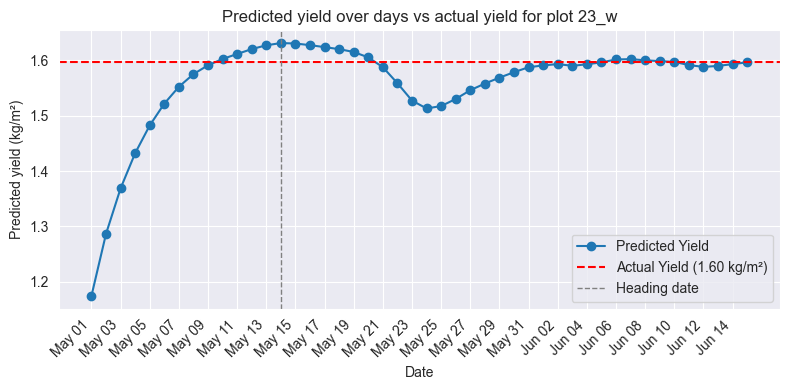

In [69]:
from plots import plot_predicted_yield

#146 is the heading date for plot 14_d
#135 is the heading date for plot 23_w
plot_predicted_yield(total_n_days, y_pred_list, actual_yield, 135, "23_w")


In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_12.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_12.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_12.save")